In [1]:
# pip install chronos-forecasting
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Optional, Tuple
from sklearn.metrics import mean_squared_error
from chronos import ChronosPipeline
from transformers import get_cosine_schedule_with_warmup
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [2]:
def smallest_int_dtype(min_val: int, max_val: int, signed: bool = True) -> str:
    if signed:
        for t in ["int8", "int16", "int32"]:
            info = np.iinfo(t)
            if info.min <= min_val <= max_val <= info.max:
                return t
        return "int64"
    else:
        for t in ["uint8", "uint16", "uint32"]:
            if 0 <= min_val <= max_val <= np.iinfo(t).max:
                return t
        return "uint64"


def optimize_df_for_memory(df: pd.DataFrame) -> tuple:
    meta = {}
    for col in df.columns:
        s = df[col]
        unique_non_null = set(df[col].dropna().unique())
        if unique_non_null.issubset({0, 1, True, False}) and col == "Група":
            df[col] = s.astype("bool")
            meta[col] = {"stored_as": "bool", "scale": 1}
            continue
        if pd.api.types.is_integer_dtype(s):
            mn, mx = int(s.min()), int(s.max())
            dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
            df[col] = s.astype(dtype)
            meta[col] = {"stored_as": dtype, "scale": 1}
            continue
        if pd.api.types.is_float_dtype(s):
            non_null = s.dropna()
            if len(non_null) == 0:
                df[col] = s.astype("float32")
                meta[col] = {"stored_as": "float32", "scale": 1}
                continue
            decimals = non_null.astype(str).apply(
                lambda x: len(x.split(".")[1].rstrip("0")) if "." in x else 0
            ).max()
            if decimals <= 3:
                scale = 10 ** decimals
                scaled = np.round(s * scale)
                mn, mx = int(np.nanmin(scaled)), int(np.nanmax(scaled))
                int_dtype = smallest_int_dtype(mn, mx, signed=(mn < 0))
                if np.dtype(int_dtype).itemsize < np.dtype("float32").itemsize:
                    df[col] = scaled.astype(int_dtype)
                    meta[col] = {"stored_as": int_dtype, "scale": scale}
                    continue
            df[col] = s.astype("float32")
            meta[col] = {"stored_as": "float32", "scale": 1}
    return df, meta

In [3]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / np.maximum(denom, 1e-8))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [4]:
TRAIN_PATH = "../data/silver_money_calc/train.parquet"
VAL_PATH   = "../data/silver_money_calc/val.parquet"
TEST_PATH  = "../data/silver_money_calc/test.parquet"

Y_COL     = "Sum of кВт"
GROUP_COL = "EIC-код_cat"

# ── Chronos hyperparams ───────────────────────────────────────────────────────
CHRONOS_MODEL_ID = "amazon/chronos-t5-small"  # tiny | mini | small | base | large
CONTEXT_LEN      = 512    # hours of history fed as encoder input
PRED_LEN         = 48     # hours to forecast
TRAIN_STRIDE     = 24     # step between training windows (hours)
BATCH_SIZE       = 32
EPOCHS           = 10
LR               = 1e-4
WARMUP_STEPS     = 200
NUM_SAMPLES      = 20     # MC samples for median forecast during eval
SAVE_PATH        = "../checkpoints/chronos_finetuned.pt"

weather_cols_to_drop = [
    "apparent_temperature", "rain", "snowfall",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "surface_pressure", "wind_direction_10m", "wind_gusts_10m",
    "diffuse_radiation", "direct_normal_irradiance",
]

In [5]:
GLOBAL_MIN_DT = None


def build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    global GLOBAL_MIN_DT
    df["datetime"] = pd.to_datetime(df["datetime"])
    if GLOBAL_MIN_DT is None:
        GLOBAL_MIN_DT = df["datetime"].min()
    df["time_idx"] = (
        (df["datetime"] - GLOBAL_MIN_DT).dt.total_seconds() / 3600
    ).astype(int)
    return df


def load_and_prepare(path: str, has_y: bool = True) -> pd.DataFrame:
    df = pd.read_parquet(path).reset_index(drop=True)
    df = df[df["datetime"] >= "2024-06-30"].reset_index(drop=True)
    df.columns = df.columns.str.replace(".", "_", regex=False)
    df, _ = optimize_df_for_memory(df)
    for col in df.select_dtypes(
        include=["int8", "int16", "int32", "uint8", "uint16", "uint32"]
    ).columns:
        df[col] = df[col].astype("float32")
    df = build_time_index(df)
    if has_y:
        df[Y_COL] = df[Y_COL].astype("float32")
    else:
        df[Y_COL] = 0.0
    df = df.sort_values([GROUP_COL, "time_idx"]).reset_index(drop=True)
    try:
        df.drop(columns=["Ціна розподілу ЕЕ", "Ціна ЕЕ", "Money_spent"], inplace=True)
    except KeyError:
        pass
    df.drop(columns=[c for c in weather_cols_to_drop if c in df.columns], inplace=True)
    return df

In [6]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH)

print("Loading test  …")
test = load_and_prepare(TEST_PATH)

print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
train: (3309985, 18)  range: 2024-06-30 00:00:00+03:00 → 2025-06-30 23:00:00+03:00
Loading val   …
Loading test  …
val : (304499, 18)
test: (304152, 18)


In [7]:
station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)
sampled_stations = station_stats[GROUP_COL].values
print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 409
Train rows : 3,309,985
Val rows   : 304,499
Test rows  : 303,408


In [8]:
train["data_subset"] = "train"
val["data_subset"]   = "val"
test["data_subset"]  = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

all_data["datetime"] = pd.to_datetime(all_data["datetime"], utc=True, errors="coerce")
all_data["datetime"] = all_data["datetime"].dt.tz_convert(None)
all_data["time_idx"] = (
    (all_data["datetime"] - all_data["datetime"].min()).dt.total_seconds() // 3600
).astype("int64")

training_cutoff = all_data.loc[all_data["data_subset"] == "train", "time_idx"].max()
val_cutoff      = all_data.loc[all_data["data_subset"] == "val",   "time_idx"].max()
test_cutoff     = all_data.loc[all_data["data_subset"] == "test",  "time_idx"].max()
all_data.drop(columns=["data_subset"], inplace=True)

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 8783
val cutoff      : 9527
test cutoff     : 10272


In [9]:
def build_series_dict(df: pd.DataFrame) -> Dict[str, dict]:
    """Per-station dict with sorted values and time_idx arrays."""
    out = {}
    for eic, grp in df.groupby(GROUP_COL):
        grp = grp.sort_values("time_idx")
        out[eic] = {
            "values":   grp[Y_COL].values.astype(np.float32),
            "time_idx": grp["time_idx"].values.astype(np.int64),
        }
    return out


def fill_nan(arr: np.ndarray) -> np.ndarray:
    """Linear interpolation + boundary fill for any NaN values."""
    if not np.isnan(arr).any():
        return arr
    return pd.Series(arr).interpolate(method="linear", limit_direction="both").values.astype(np.float32)


# Training series (context window ends at training_cutoff)
train_series_dict = build_series_dict(
    all_data[all_data["time_idx"] <= training_cutoff]
)
# Full series for rolling eval (all splits)
full_series_dict = build_series_dict(all_data)

lengths = [len(v["values"]) for v in train_series_dict.values()]
print(f"Stations        : {len(train_series_dict)}")
print(f"Train series len: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.0f}")

Stations        : 409
Train series len: min=25, max=8806, mean=8115


In [10]:
class ChronosWindowDataset(Dataset):
    """
    Slides a (context_len, pred_len) window over each station's training series.
    Returns (context_array, target_array) as float32 numpy arrays.
    """

    def __init__(
        self,
        series_dict: Dict[str, dict],
        context_len: int = 512,
        pred_len: int = 48,
        stride: int = 24,
    ):
        self.windows: List[Tuple[np.ndarray, np.ndarray]] = []
        min_len = context_len + pred_len
        for eic, data in series_dict.items():
            ts = fill_nan(data["values"])
            if len(ts) < min_len:
                continue
            for start in range(0, len(ts) - min_len + 1, stride):
                ctx = ts[start : start + context_len].copy()
                tgt = ts[start + context_len : start + context_len + pred_len].copy()
                self.windows.append((ctx, tgt))

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray]:
        return self.windows[idx]


def collate_windows(batch):
    ctx = torch.tensor(np.stack([b[0] for b in batch]), dtype=torch.float32)
    tgt = torch.tensor(np.stack([b[1] for b in batch]), dtype=torch.float32)
    return ctx, tgt


dataset = ChronosWindowDataset(train_series_dict, CONTEXT_LEN, PRED_LEN, TRAIN_STRIDE)
loader  = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_windows, num_workers=0, pin_memory=True,
)
print(f"Training windows : {len(dataset):,}")
print(f"Batches per epoch: {len(loader):,}")

Training windows : 128,946
Batches per epoch: 4,030


In [11]:
pipeline = ChronosPipeline.from_pretrained(
    CHRONOS_MODEL_ID,
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

# inner_model is T5ForConditionalGeneration; fine-tune it directly
inner_model: torch.nn.Module = pipeline.model.model
tokenizer = pipeline.tokenizer

# Override prediction length so label_input_transform accepts PRED_LEN-sized targets.
# This fine-tunes specifically for the 48-hour horizon instead of the default 64.
tokenizer.config.prediction_length = PRED_LEN

n_params = sum(p.numel() for p in inner_model.parameters())
print(f"Loaded  : {CHRONOS_MODEL_ID}")
print(f"Params  : {n_params:,}  ({n_params / 1e6:.1f} M)")
print(f"Device  : {next(inner_model.parameters()).device}")
print(f"Train pred len: {tokenizer.config.prediction_length}")

Loaded  : amazon/chronos-t5-small
Params  : 46,154,240  (46.2 M)
Device  : cuda:0
Train pred len: 48


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1:   0%|          | 0/4030 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch  1  |  avg loss: 2.3394


  Epoch 2:   0%|          | 0/4030 [00:00<?, ?it/s]

...

Epoch  8  |  avg loss: 2.2949


  Epoch 9:   0%|          | 0/4030 [00:00<?, ?it/s]

Epoch  9  |  avg loss: 2.2949


  Epoch 10:   0%|          | 0/4030 [00:00<?, ?it/s]

Epoch 10  |  avg loss: 2.2951


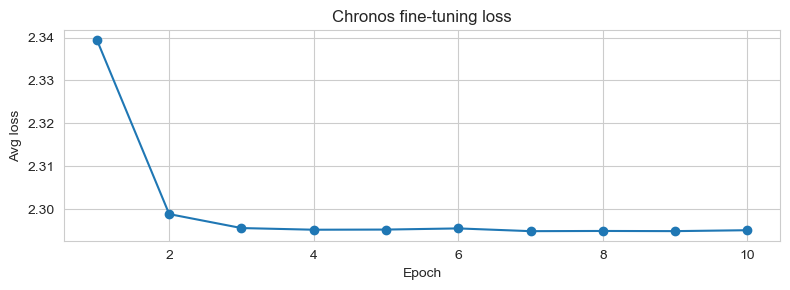

In [12]:
def compute_loss(
    inner_model: torch.nn.Module,
    tokenizer,
    ctx_batch: torch.Tensor,  # [B, context_len]
    tgt_batch: torch.Tensor,  # [B, pred_len]
    device: torch.device,
) -> torch.Tensor:
    # context_input_transform expects a Tensor [B, L], not a list
    input_ids, attention_mask, scale = tokenizer.context_input_transform(ctx_batch)
    label_ids, _                     = tokenizer.label_input_transform(tgt_batch, scale)

    output = inner_model(
        input_ids=input_ids.to(device),
        attention_mask=attention_mask.to(device),
        labels=label_ids.to(device),
    )
    return output.loss


optimizer = torch.optim.AdamW(
    inner_model.parameters(), lr=LR, weight_decay=1e-2
)
total_steps = len(loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

train_losses = []
inner_model.train()

for epoch in trange(1, EPOCHS + 1, desc="Epochs"):
    epoch_loss = 0.0
    bar = tqdm(loader, desc=f"  Epoch {epoch}", leave=False)

    for ctx_batch, tgt_batch in bar:
        optimizer.zero_grad()

        loss = compute_loss(inner_model, tokenizer, ctx_batch, tgt_batch, DEVICE)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(inner_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

    avg = epoch_loss / len(loader)
    train_losses.append(avg)
    print(f"Epoch {epoch:2d}  |  avg loss: {avg:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Avg loss")
plt.title("Chronos fine-tuning loss")
plt.tight_layout()
plt.show()

In [13]:
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(inner_model.state_dict(), SAVE_PATH)
print(f"Checkpoint saved → {SAVE_PATH}")

# To reload later:
# pipeline = ChronosPipeline.from_pretrained(CHRONOS_MODEL_ID, device_map="cuda", torch_dtype=torch.bfloat16)
# pipeline.model.model.load_state_dict(torch.load(SAVE_PATH))

Checkpoint saved → checkpoints/chronos_finetuned.pt


In [14]:
inner_model.eval()


def rolling_forecast_station(
    eic: str,
    start_cutoff: int,
    end_cutoff: int,
) -> List[dict]:
    """
    Predicts in 48-hour blocks from start_cutoff+1 to end_cutoff (inclusive)
    using all data up to the current position as context.
    """
    data   = full_series_dict[eic]
    values = fill_nan(data["values"])
    tidx   = data["time_idx"]

    start_pos = int(np.searchsorted(tidx, start_cutoff, side="right"))
    end_pos   = int(np.searchsorted(tidx, end_cutoff,   side="right"))

    rows = []
    pos  = start_pos
    while pos < end_pos:
        ctx_start = max(0, pos - CONTEXT_LEN)
        context   = torch.tensor(values[ctx_start:pos], dtype=torch.float32).unsqueeze(0)

        remaining = end_pos - pos
        step_len  = min(PRED_LEN, remaining)

        with torch.no_grad():
            forecast = pipeline.predict(
                context=context,
                prediction_length=PRED_LEN,
                num_samples=NUM_SAMPLES,
            )

        median = np.quantile(forecast[0].cpu().numpy(), 0.5, axis=0)

        for i in range(step_len):
            rows.append({
                GROUP_COL: eic,
                "time_idx": int(tidx[pos + i]),
                "pred":     float(median[i]),
                Y_COL:      float(values[pos + i]),
            })
        pos += PRED_LEN

    return rows


def run_rolling_eval(split: str, start_cutoff: int, end_cutoff: int) -> pd.DataFrame:
    all_rows = []
    for eic in tqdm(list(full_series_dict.keys()), desc=f"Rolling forecast ({split})"):
        all_rows.extend(rolling_forecast_station(eic, start_cutoff, end_cutoff))
    return pd.DataFrame(all_rows)


val_eval  = run_rolling_eval("val",  training_cutoff, val_cutoff)
test_eval = run_rolling_eval("test", val_cutoff,      test_cutoff)

print(f"val_eval  : {len(val_eval):,} rows")
print(f"test_eval : {len(test_eval):,} rows")

Rolling forecast (val):   0%|          | 0/409 [00:00<?, ?it/s]

Rolling forecast (test):   0%|          | 0/409 [00:00<?, ?it/s]

val_eval  : 304,499 rows
test_eval : 294,277 rows


In [15]:
print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ──────────────1    q──────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────
Aligned samples : 304,499
SMAPE : 0.0709
RMSE  : 8.2377
MAPE  : 9.26 %

── Test ────────────────────────────────────────────────────
Aligned samples : 294,277
SMAPE : 0.0570
RMSE  : 8.2098
MAPE  : 9.75 %


In [16]:
def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

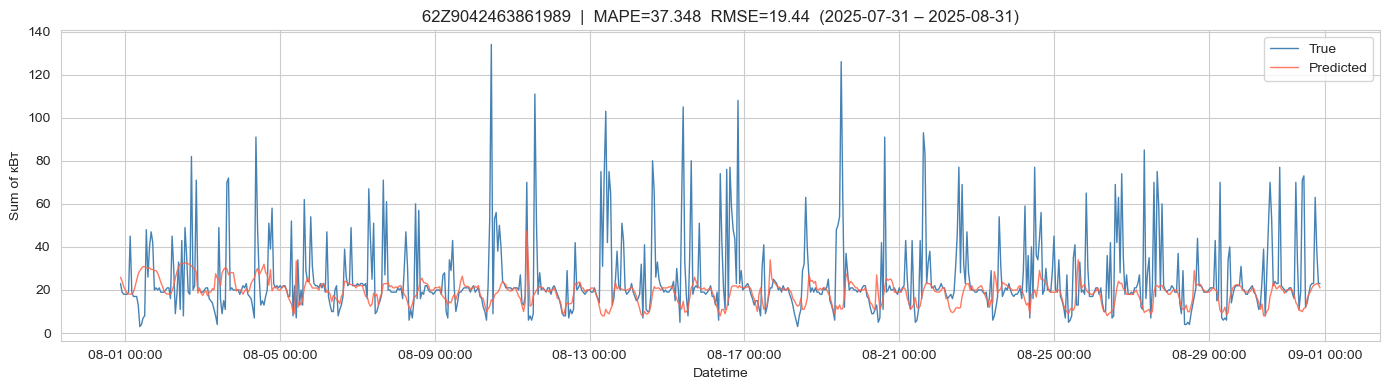

In [22]:
plot_forecast(test_eval,  eic_code='62Z9042463861989')

In [19]:
test

,EIC-код_cat,Група_cat,Sum of кВт,АЗС_cat,Тип_cat,Область_cat,Широта,Довгота,ОСР код_cat,ОСР опис_cat,datetime,temperature_2m,dew_point_2m,relative_humidity_2m,precipitation,wind_speed_10m,shortwave_radiation,time_idx,data_subset
0,62Z0008583037334,1.0,19.000000,АЗС_29,ОККО-комплекс,Закарпатська,48.442429,22.192190,MGA-00700,Ужгород,2025-07-31 01:00:00+03:00,164.0,134.0,82.0,0.0,57.0,0.0,9505,test
1,62Z0008583037334,1.0,17.000000,АЗС_29,ОККО-комплекс,Закарпатська,48.442429,22.192190,MGA-00700,Ужгород,2025-07-31 02:00:00+03:00,156.0,134.0,87.0,0.0,49.0,0.0,9506,test
2,62Z0008583037334,1.0,16.000000,АЗС_29,ОККО-комплекс,Закарпатська,48.442429,22.192190,MGA-00700,Ужгород,2025-07-31 03:00:00+03:00,146.0,133.0,92.0,0.0,13.0,0.0,9507,test
3,62Z0008583037334,1.0,15.000000,АЗС_29,ОККО-комплекс,Закарпатська,48.442429,22.192190,MGA-00700,Ужгород,2025-07-31 04:00:00+03:00,144.0,134.0,93.0,0.0,10.0,0.0,9508,test
4,62Z0008583037334,1.0,15.000000,АЗС_29,ОККО-комплекс,Закарпатська,48.442429,22.192190,MGA-00700,Ужгород,2025-07-31 05:00:00+03:00,142.0,132.0,94.0,0.0,22.0,0.0,9509,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303403,62Z9997819406173,0.0,22.540932,АЗС_65,ОККО-міська,Львівська,49.800007,24.068964,MGA-00900,Львів,2025-08-31 20:00:00+03:00,205.0,176.0,83.0,0.0,156.0,0.0,10268,test
303404,62Z9997819406173,0.0,24.207382,АЗС_65,ОККО-міська,Львівська,49.800007,24.068964,MGA-00900,Львів,2025-08-31 21:00:00+03:00,202.0,172.0,83.0,0.0,156.0,0.0,10269,test
303405,62Z9997819406173,0.0,25.211151,АЗС_65,ОККО-міська,Львівська,49.800007,24.068964,MGA-00900,Львів,2025-08-31 22:00:00+03:00,198.0,171.0,85.0,0.0,147.0,0.0,10270,test
303406,62Z9997819406173,0.0,22.579912,АЗС_65,ОККО-міська,Львівська,49.800007,24.068964,MGA-00900,Львів,2025-08-31 23:00:00+03:00,194.0,171.0,87.0,0.0,141.0,0.0,10271,test
